In [9]:

import pandas as pd

df=pd.read_csv('/content/social_media_engagement_5000.csv'
)

df.head()

,user_id,age,gender,country,post_id,post_type,post_category,likes,comments,shares,watch_time_sec,impression_count,posted_at,follower_count,is_verified,device_type,sentiment,hashtags,engagement_rate
0,25795,43.0,Female,Brazil,496713,image,fitness,7011.0,354.0,1157.0,5726,44650,17-12-2022,81734,False,mobile,negative,#foodie #travel #love,0.190862
1,10860,33.0,Male,Brazil,157326,reel,food,11750.0,2606.0,1807.0,5947,80216,02-06-2023,5963,False,mobile,negative,#fitness,0.201493
2,86820,32.0,Female,UK,109864,text,food,4862.0,344.0,955.0,6946,44858,07-05-2023,501783,False,tablet,positive,#foodie,0.137345
3,64886,51.0,Other,France,848877,text,fitness,5350.0,1083.0,1049.0,229,70455,12-02-2023,480212,False,mobile,negative,#music #foodie #fun,0.106195
4,16265,34.0,Other,UK,449706,image,fitness,12682.0,2735.0,1300.0,4798,6019,23-05-2023,383936,False,mobile,negative,#travel,2.777372


In [4]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import plotly.express as px

df = pd.read_csv("social_media_engagement_5000.csv")
print(df.dtypes)
df["posted_at"] = pd.to_datetime(df["posted_at"], format="%d-%m-%Y", errors="coerce")
df["is_verified"] = df["is_verified"].astype(str).str.upper().map({"TRUE": True, "FALSE": False})

user_id               int64
age                 float64
gender               object
country              object
post_id               int64
post_type            object
post_category        object
likes               float64
comments            float64
shares              float64
watch_time_sec        int64
impression_count      int64
posted_at            object
follower_count        int64
is_verified            bool
device_type          object
sentiment            object
hashtags             object
engagement_rate     float64
dtype: object


In [10]:
# Display the first 5 rows
df.head()

# Display the first 10 rows
df.head(10)

# Display all 5000 rows (not recommended for large datasets)
df

# Check total rows and columns
df.shape

(5000, 19)

In [5]:
# Data Cleaning
# Missing values
print(df.isnull().sum())
for c in ["age", "likes", "comments", "shares"]:
    df[c] = df[c].fillna(df[c].median())
df["gender"] = df["gender"].fillna(df["gender"].mode()[0])
df["sentiment"] = df["sentiment"].fillna("neutral")
df["posted_at"] = df["posted_at"].ffill().bfill()

# Duplicates (user_id repeats are normal, so check full rows and post_id)
print(df.duplicated().sum(), df["post_id"].duplicated().sum())
df = df.drop_duplicates().drop_duplicates(subset="post_id").reset_index(drop=True)

# Standardize categories
for c in ["gender", "post_type", "post_category", "country", "device_type", "sentiment"]:
    df[c] = df[c].astype(str).str.strip().str.title()

# Unrealistic values
df = df[(df["likes"] >= 0) & (df["comments"] >= 0) & (df["shares"] >= 0)]
df = df[(df["age"] >= 13) & (df["age"] <= 100)]
df["total_interactions"] = df["likes"] + df["comments"] + df["shares"]
print("Rows with interactions > impressions:", (df["total_interactions"] > df["impression_count"]).sum())
df = df[df["total_interactions"] <= df["impression_count"]]   # engagement_rate must be <= 1
df["engagement_rate"] = df["total_interactions"] / df["impression_count"]  # recompute after imputing

# Feature cleaning
df["hashtag_count"] = df["hashtags"].fillna("").str.count("#")
df["sentiment"] = df["sentiment"].replace({"": "Neutral", "Nan": "Neutral"})
df = df.reset_index(drop=True)

user_id               0
age                 150
gender              150
country               0
post_id               0
post_type             0
post_category         0
likes               150
comments            150
shares              150
watch_time_sec        0
impression_count      0
posted_at             0
follower_count        0
is_verified           0
device_type           0
sentiment           150
hashtags              0
engagement_rate       0
dtype: int64
0 9
Rows with interactions > impressions: 599


In [6]:
#Data Exploration
print(df.head(), df.tail(), df.shape, df.columns, sep="\n")
df.info(); print(df.dtypes)
print(df.describe())
for c in ["gender", "country", "post_type", "post_category", "device_type", "sentiment"]:
    print(df[c].value_counts(), df[c].unique(), df[c].nunique(), sep="\n")
num = ["age", "likes", "comments", "shares", "watch_time_sec", "impression_count",
       "follower_count", "engagement_rate", "hashtag_count"]
corr = df[num].corr()
print(corr)
print(df.groupby("post_type")["likes"].mean())
print(df.groupby("country")["impression_count"].sum())

   user_id   age  gender country  post_id post_type post_category    likes  \
0    25795  43.0  Female  Brazil   496713     Image       Fitness   7011.0   
1    10860  33.0    Male  Brazil   157326      Reel          Food  11750.0   
2    86820  32.0  Female      Uk   109864      Text          Food   4862.0   
3    64886  51.0   Other  France   848877      Text       Fitness   5350.0   
4    92386  16.0   Other  Canada   174310     Video          Tech  12535.0   

   comments  shares  ...  impression_count  posted_at follower_count  \
0     354.0  1157.0  ...             44650 2022-12-17          81734   
1    2606.0  1807.0  ...             80216 2023-06-02           5963   
2     344.0   955.0  ...             44858 2023-05-07         501783   
3    1083.0  1049.0  ...             70455 2023-02-12         480212   
4    1790.0    99.0  ...             24893 2023-09-16         684761   

   is_verified  device_type sentiment               hashtags engagement_rate  \
0        False    

In [7]:
#Data Wrangling
df["engagement_score"] = df["likes"] + 2*df["comments"] + 3*df["shares"]
df["log_impressions"] = np.log1p(df["impression_count"])
df["log_likes"] = np.log1p(df["likes"])
df["day_of_week"] = df["posted_at"].dt.day_name()
df["month"] = df["posted_at"].dt.to_period("M").astype(str)

# merge demo: country average engagement joined back
country_avg = df.groupby("country", as_index=False)["engagement_rate"].mean() \
                .rename(columns={"engagement_rate": "country_avg_er"})
df = df.merge(country_avg, on="country", how="left")

cols = ["likes", "comments", "shares", "impression_count", "engagement_rate", "engagement_score"]
for g in ["post_type", "country", "sentiment"]:
    print(df.groupby(g)[cols].mean().round(3), "\n")

              likes  comments    shares  impression_count  engagement_rate  \
post_type                                                                    
Image      9727.662  1523.318  1015.514         55290.306            0.290   
Reel       9711.188  1490.388   972.899         55664.558            0.281   
Text       9722.608  1487.702  1004.451         56152.112            0.286   
Video      9832.689  1462.003   992.892         56141.336            0.285   

           engagement_score  
post_type                    
Image             15820.840  
Reel              15610.663  
Text              15711.365  
Video             15735.371   

               likes  comments    shares  impression_count  engagement_rate  \
country                                                                       
Australia  10019.245  1467.684  1010.664         56101.737            0.284   
Brazil      9463.148  1469.357   997.802         55078.795            0.283   
Canada      9753.077  1578.965   

In [8]:
#Statistical analysis
cols = ["likes", "comments", "shares", "watch_time_sec", "engagement_rate", "follower_count"]
stats = df[cols].agg(["mean", "median", "std", "var", "skew", "kurt"]).T
stats["mode"] = [df[c].mode()[0] for c in cols]
stats = stats.join(df[cols].quantile([.25, .5, .75, .9]).T.rename(
    columns={.25: "p25", .5: "p50", .75: "p75", .9: "p90"}))
print(stats)

                          mean         median            std           var  \
likes              9747.625342    9880.500000    5680.715312  3.227053e+07   
comments           1491.082650    1497.000000     856.550427  7.336786e+05   
shares              996.219262    1012.000000     570.412692  3.253706e+05   
watch_time_sec     3991.910291    3996.000000    2311.553352  5.343279e+06   
engagement_rate       0.285649       0.226066       0.208995  4.367882e-02   
follower_count   394536.821721  390900.000000  230713.668378  5.322880e+10   

                     skew      kurt           mode            p25  \
likes            0.063200 -1.136364   10105.500000    4840.750000   
comments         0.008692 -1.149040    1497.000000     781.250000   
shares          -0.009623 -1.148677    1012.000000     505.000000   
watch_time_sec  -0.002911 -1.204103     916.000000    1974.000000   
engagement_rate  1.309233  1.271071       0.006363       0.135026   
follower_count   0.029032 -1.186138  49

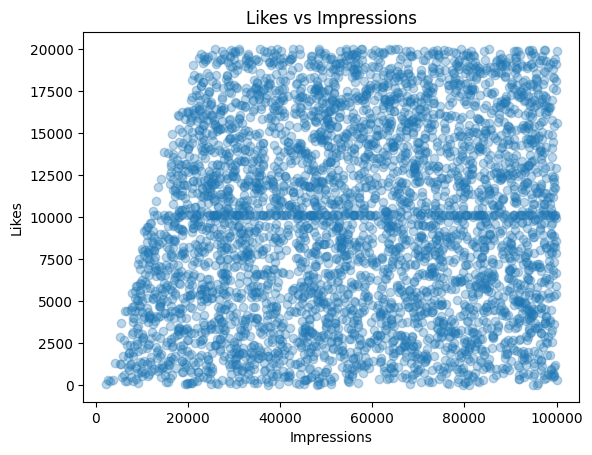

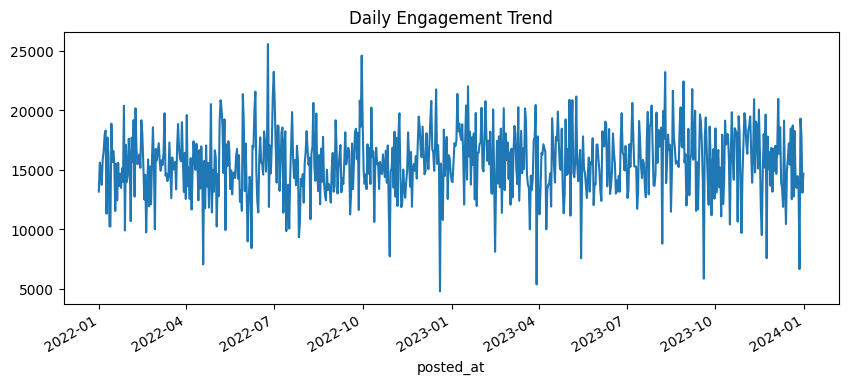

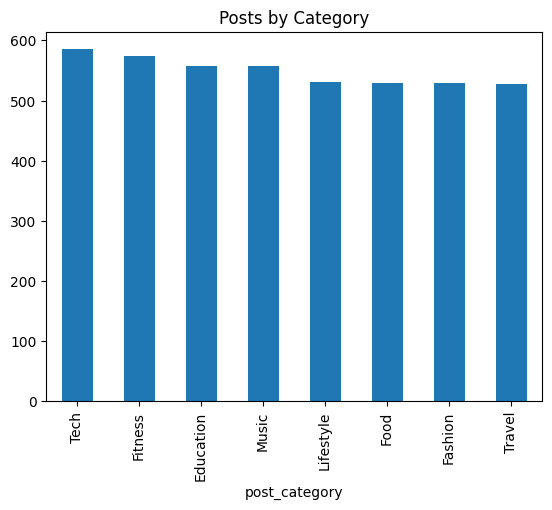

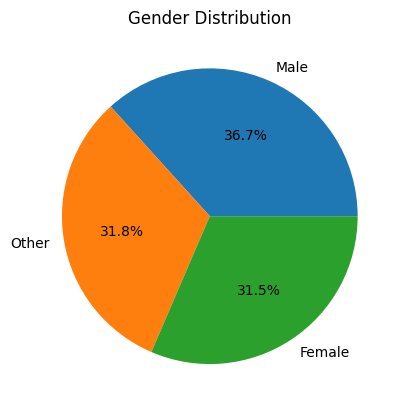

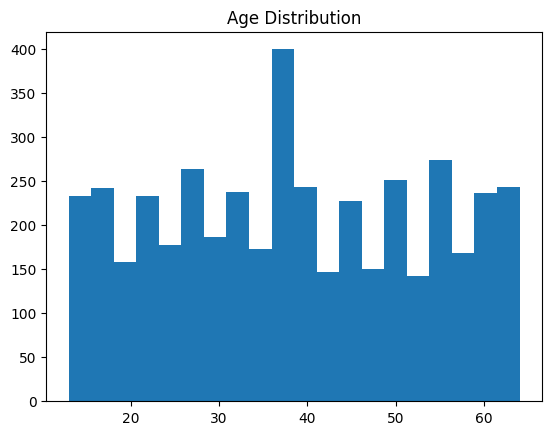

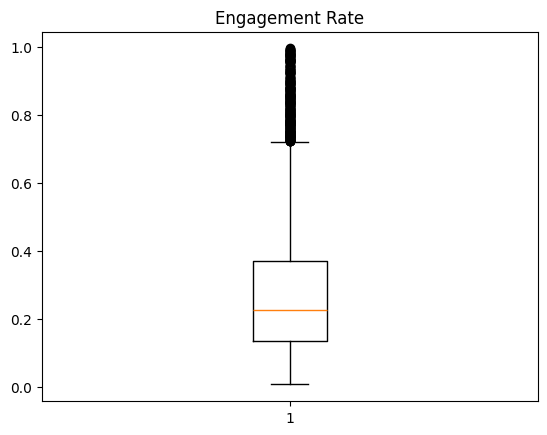

In [ ]:
#Matplotlib
plt.scatter(df["impression_count"], df["likes"], alpha=.3)
plt.xlabel("Impressions"); plt.ylabel("Likes"); plt.title("Likes vs Impressions"); plt.show()

df.groupby("posted_at")["engagement_score"].mean().plot(figsize=(10,4), title="Daily Engagement Trend"); plt.show()
df["post_category"].value_counts().plot(kind="bar", title="Posts by Category"); plt.show()
df["gender"].value_counts().plot(kind="pie", autopct="%1.1f%%", title="Gender Distribution"); plt.ylabel(""); plt.show()
plt.hist(df["age"], bins=20); plt.title("Age Distribution"); plt.show()
plt.boxplot(df["engagement_rate"]); plt.title("Engagement Rate"); plt.show()

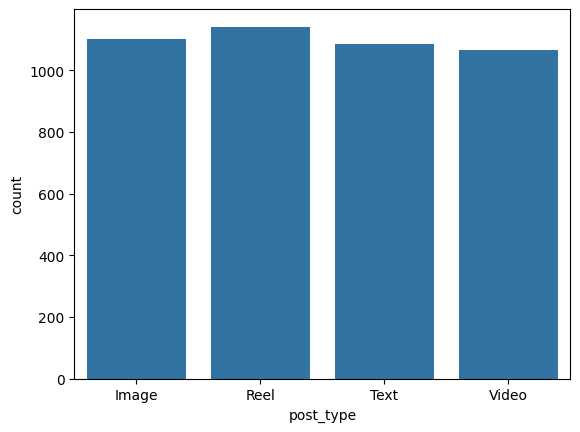

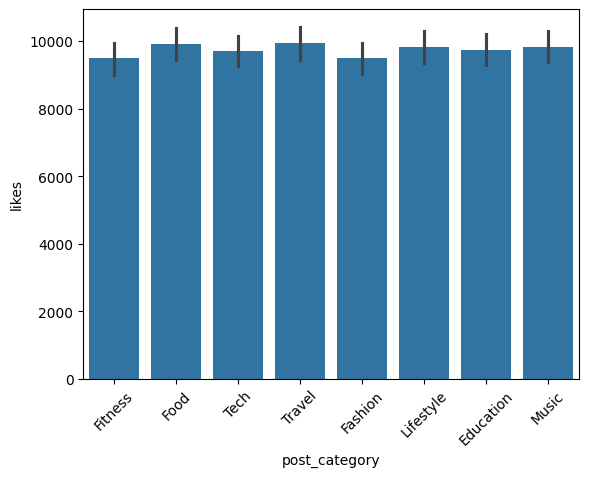

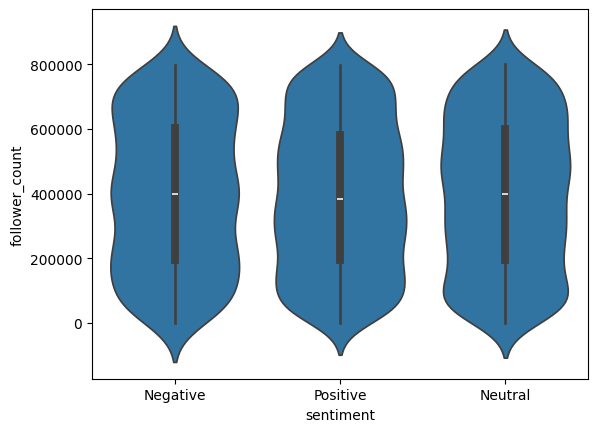

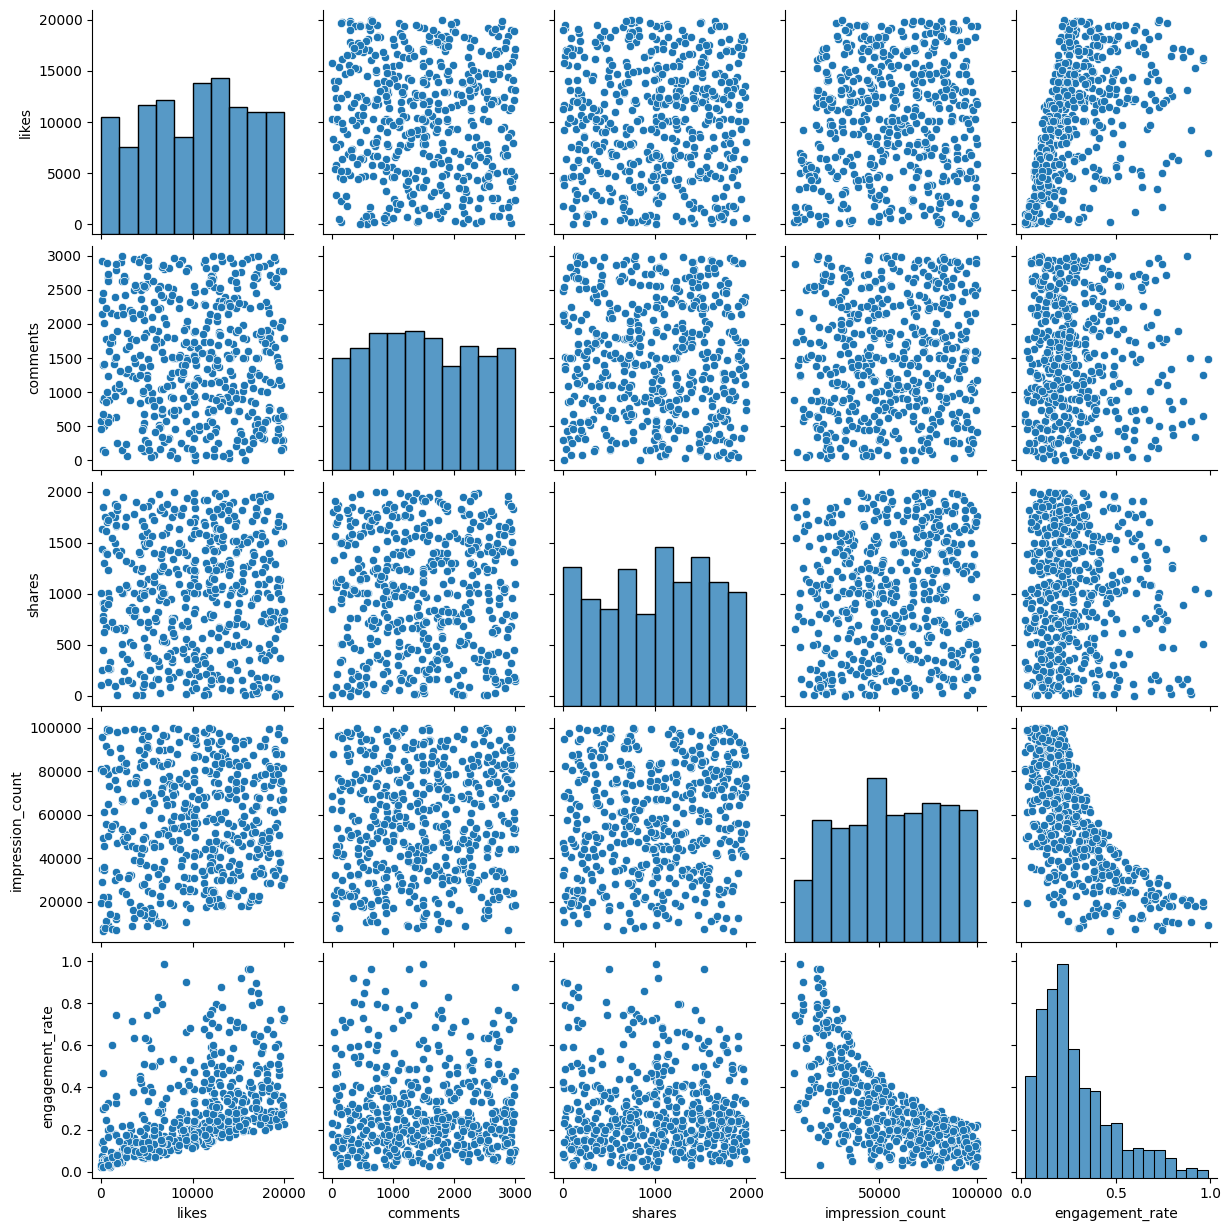

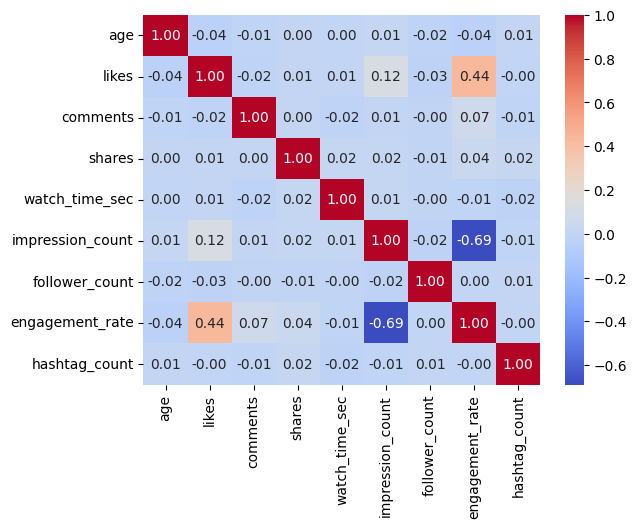

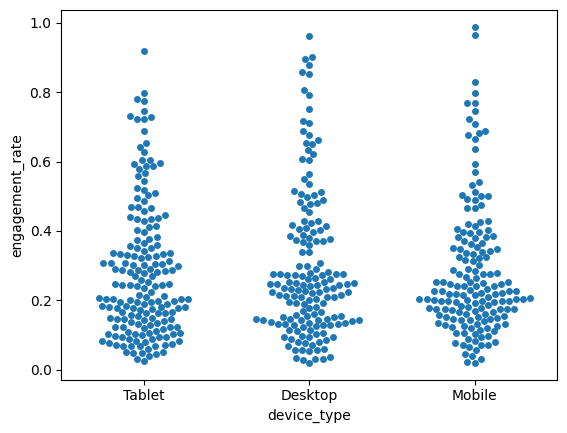

In [ ]:
#Seaborn
sns.countplot(data=df, x="post_type"); plt.show()
sns.barplot(data=df, x="post_category", y="likes"); plt.xticks(rotation=45); plt.show()
sns.violinplot(data=df, x="sentiment", y="follower_count"); plt.show()
sns.pairplot(df[["likes", "comments", "shares", "impression_count", "engagement_rate"]].sample(500, random_state=1)); plt.show()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm"); plt.show()
sns.swarmplot(data=df.sample(500, random_state=1), x="device_type", y="engagement_rate"); plt.show()

In [ ]:
#Plotly
px.scatter(df, x="impression_count", y="likes", size="shares", color="post_type",
           title="Likes vs Impressions (bubble = shares)").show()
daily = df.groupby("posted_at", as_index=False)["engagement_score"].mean()
px.line(daily, x="posted_at", y="engagement_score", title="Daily Engagement").show()
px.bar(df.groupby("country", as_index=False)["engagement_rate"].mean(),
       x="country", y="engagement_rate", title="Avg Engagement Rate by Country").show()

post_type
Image    0.290492
Text     0.286233
Video    0.284677
Reel     0.281332
Name: engagement_rate, dtype: float64
post_category
Education    0.294546
Music        0.294383
Fashion      0.288261
Food         0.283923
Lifestyle    0.282936
Tech         0.282549
Travel       0.280913
Fitness      0.277745
Name: engagement_rate, dtype: float64
country
Germany      0.309150
Canada       0.298106
Japan        0.288345
Uae          0.284538
Uk           0.284068
Australia    0.283706
Brazil       0.283181
India        0.282170
Usa          0.276078
France       0.266841
Name: engagement_rate, dtype: float64
age_group
13-17    0.309007
18-25    0.290692
26-35    0.287684
36-50    0.283745
51+      0.275638
Name: engagement_rate, dtype: float64
             engagement_rate        likes  engagement_score
is_verified                                                
False               0.288360  9794.023672      15763.092924
True                0.260074  9309.982185      15297.347981
day_of_w